In [1]:
import os
import random
import datetime
import pickle

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

AUTOTUNE = tf.data.AUTOTUNE

SEEDS = [42, 123, 2024, 3407, 777]

BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 5
IMAGE_SIZE = (224, 224)
LEARNING_RATE = 1e-5
FINE_TUNE_LAYERS = 20

AUTOTUNE = tf.data.AUTOTUNE



2026-05-10 10:50:53.448714: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778410253.648907      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778410253.704419      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778410254.137573      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778410254.137612      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778410254.137615      23 computation_placer.cc:177] computation placer alr

In [2]:
DATASET_DIR = "/kaggle/input/datasets/shahadhossin567r7455/potato-leaf-disease-dataset/Potato Leaf DIsease"

class_names = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

NUM_CLASSES = len(class_names)

print("Detected classes:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print("Number of classes:", NUM_CLASSES)

assert NUM_CLASSES == 7, f"Expected 7 classes, but found {NUM_CLASSES}"


Detected classes:
0: Early Blight
1: Fungal Diseases
2: Healthy
3: Late Blight
4: Plant Pests
5: Potato Cyst Nematode
6: Potato Virus
Number of classes: 7


In [3]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

file_paths = []
labels = []

for label_index, class_name in enumerate(class_names):
    class_dir = os.path.join(DATASET_DIR, class_name)

    for fname in os.listdir(class_dir):
        if fname.lower().endswith(valid_extensions):
            file_paths.append(os.path.join(class_dir, fname))
            labels.append(label_index)

file_paths = np.array(file_paths)
labels = np.array(labels)

print("Total images:", len(labels))

unique, counts = np.unique(labels, return_counts=True)
print("\nClass distribution:")
for idx, count in zip(unique, counts):
    print(f"{class_names[idx]}: {count}")


Total images: 3500

Class distribution:
Early Blight: 500
Fungal Diseases: 500
Healthy: 500
Late Blight: 500
Plant Pests: 500
Potato Cyst Nematode: 500
Potato Virus: 500


In [4]:
def load_dataset_effnet(file_paths, labels, augment=False, shuffle=True, seed=42):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    def process(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])

        image = tf.image.resize(image, IMAGE_SIZE)
        image = tf.cast(image, tf.float32)

        if augment:
            image = tf.image.random_flip_left_right(image)
            image = tf.image.random_brightness(image, max_delta=25.5)
            image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
            image = tf.clip_by_value(image, 0.0, 255.0)

        image = preprocess_input(image)
        label = tf.one_hot(label, depth=NUM_CLASSES)

        return image, label

    ds = ds.map(process, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(file_paths),
            seed=seed,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    return ds


In [5]:
def build_efficientnet_b0(num_classes=7, input_shape=(224, 224, 3)):
    inputs = tf.keras.Input(shape=input_shape)

    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    backbone.trainable = True

    for layer in backbone.layers[:-FINE_TUNE_LAYERS]:
        layer.trainable = False

    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="EfficientNetB0_7class_finetuned"
    )

    return model


In [6]:
def count_model_parameters(model):
    total_params = model.count_params()
    trainable_params = np.sum([
        np.prod(v.shape) for v in model.trainable_weights
    ])
    non_trainable_params = np.sum([
        np.prod(v.shape) for v in model.non_trainable_weights
    ])

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Non-trainable parameters: {non_trainable_params:,}")

    return total_params, trainable_params, non_trainable_params


In [7]:
def run_single_seed(seed):
    print("\n" + "=" * 70)
    print(f"Running seed: {seed}")
    print("=" * 70)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    X_train, X_temp, y_train, y_temp = train_test_split(
        file_paths,
        labels,
        test_size=0.20,
        stratify=labels,
        random_state=seed
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=seed
    )

    print(f"Train: {len(X_train)}")
    print(f"Validation: {len(X_val)}")
    print(f"Test: {len(X_test)}")

    class_weight_vals = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUM_CLASSES),
        y=y_train
    )

    class_weight = dict(enumerate(class_weight_vals))
    print("Class weights:", class_weight)

    train_ds = load_dataset_effnet(
        X_train,
        y_train,
        augment=True,
        shuffle=True,
        seed=seed
    )

    val_ds = load_dataset_effnet(
        X_val,
        y_val,
        augment=False,
        shuffle=False,
        seed=seed
    )

    test_ds = load_dataset_effnet(
        X_test,
        y_test,
        augment=False,
        shuffle=False,
        seed=seed
    )

    model = build_efficientnet_b0(num_classes=NUM_CLASSES)

    if seed == SEEDS[0]:
        count_model_parameters(model)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    os.makedirs("models", exist_ok=True)
    os.makedirs("history", exist_ok=True)

    run_name = f"EfficientNetB0_7class_seed_{seed}"

    model_path = f"models/{run_name}.keras"
    history_path = f"history/{run_name}_history.pkl"
    plot_path = f"history/{run_name}_accuracy_loss.png"
    cm_path = f"history/{run_name}_confusion_matrix.png"

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor="val_loss",
        save_best_only=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stop, checkpoint],
        class_weight=class_weight
    )

    with open(history_path, "wb") as f:
        pickle.dump(history.history, f)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    y_true = []
    y_pred = []

    for images, batch_labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(batch_labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True
    )

    print(f"\nSeed {seed} Test Accuracy: {test_acc:.4f}")
    print(f"Seed {seed} Test Loss: {test_loss:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    ))

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        xticks_rotation=45
    )
    plt.title(f"Confusion Matrix: Seed {seed}")
    plt.tight_layout()
    plt.savefig(cm_path, dpi=300)
    plt.show()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy - Seed {seed}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss - Seed {seed}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.show()

    result = {
        "seed": seed,
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "macro_precision": report_dict["macro avg"]["precision"],
        "macro_recall": report_dict["macro avg"]["recall"],
        "macro_f1": report_dict["macro avg"]["f1-score"],
        "weighted_precision": report_dict["weighted avg"]["precision"],
        "weighted_recall": report_dict["weighted avg"]["recall"],
        "weighted_f1": report_dict["weighted avg"]["f1-score"],
        "model_path": model_path,
        "history_path": history_path,
        "plot_path": plot_path,
        "confusion_matrix_path": cm_path
    }

    return result



Running seed: 42
Train: 2800
Validation: 350
Test: 350
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}


I0000 00:00:1778410278.905112      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 4,058,538
Trainable parameters: 1,359,927
Non-trainable parameters: 2,698,611.0
Epoch 1/50


I0000 00:00:1778410299.582621      65 service.cc:152] XLA service 0x7daad40544d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778410299.582677      65 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778410301.961319      65 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-10 10:51:47.662779: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 10:51:47.869229: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778410315.776816      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proc

87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2041 - loss: 1.9128

2026-05-10 10:52:05.295121: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 10:52:05.499639: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


88/88 ━━━━━━━━━━━━━━━━━━━━ 65s 362ms/step - accuracy: 0.2051 - loss: 1.9114 - val_accuracy: 0.3286 - val_loss: 1.7135
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.3933 - loss: 1.6725 - val_accuracy: 0.5571 - val_loss: 1.4789
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.5441 - loss: 1.4807 - val_accuracy: 0.6829 - val_loss: 1.3047
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6122 - loss: 1.3379 - val_accuracy: 0.7400 - val_loss: 1.1791
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6562 - loss: 1.2213 - val_accuracy: 0.7629 - val_loss: 1.0788
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.7056 - loss: 1.1122 - val_accuracy: 0.7771 - val_loss: 0.9958
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.7371 - loss: 1.0233 - val_accuracy: 0.8000 - val_loss: 0.9241
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.7496 - loss: 0.9601 - val_accuracy: 0.8086 - val_loss: 

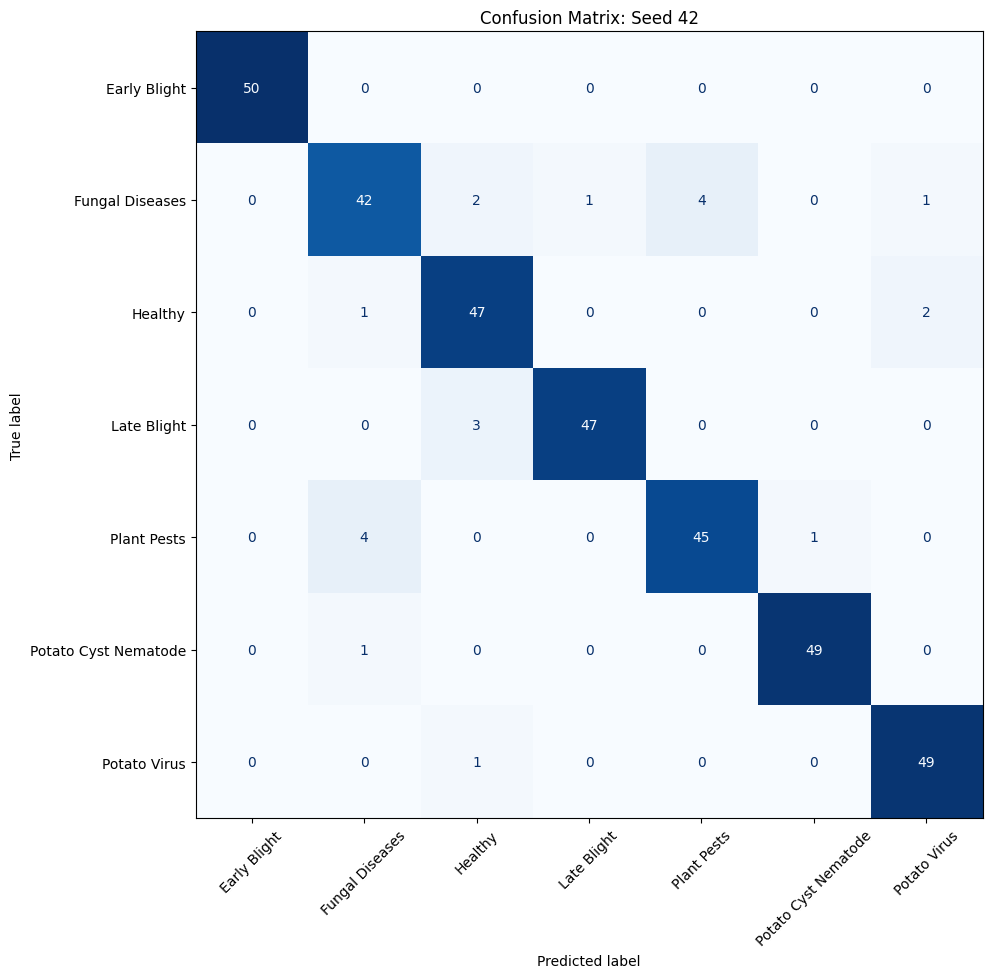

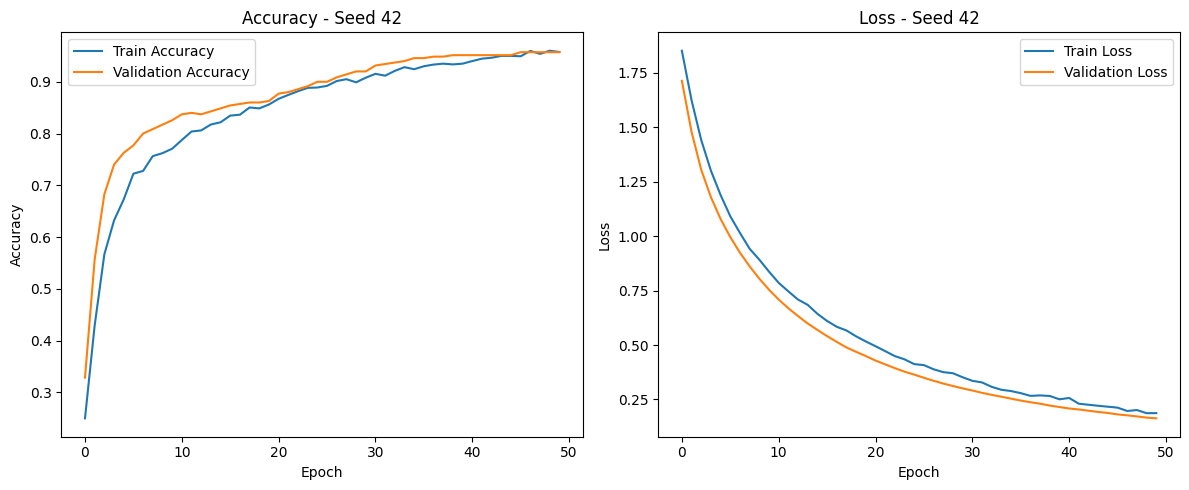


Running seed: 123
Train: 2800
Validation: 350
Test: 350
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 51s 303ms/step - accuracy: 0.1359 - loss: 2.0026 - val_accuracy: 0.3257 - val_loss: 1.7908
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.3390 - loss: 1.7557 - val_accuracy: 0.5143 - val_loss: 1.5517
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.4644 - loss: 1.5696 - val_accuracy: 0.5829 - val_loss: 1.3745
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.5901 - loss: 1.3834 - val_accuracy: 0.6571 - val_loss: 1.2433
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6587 - loss: 1.2519 - val_accuracy: 0.6943 - val_loss: 1.1386
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6782 - loss: 1.1648 - val_accuracy: 0.7114 - val_loss: 1.0566
Epoch 7/50
88/88 ━━━━━━

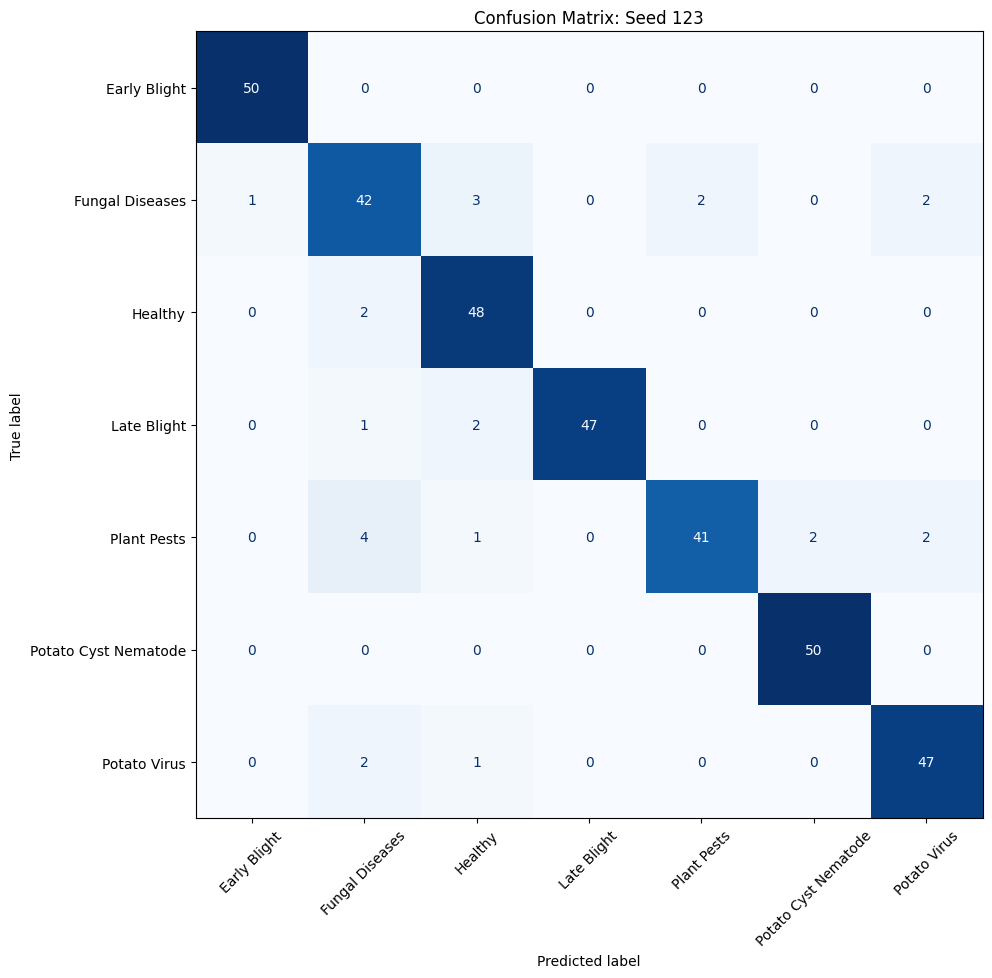

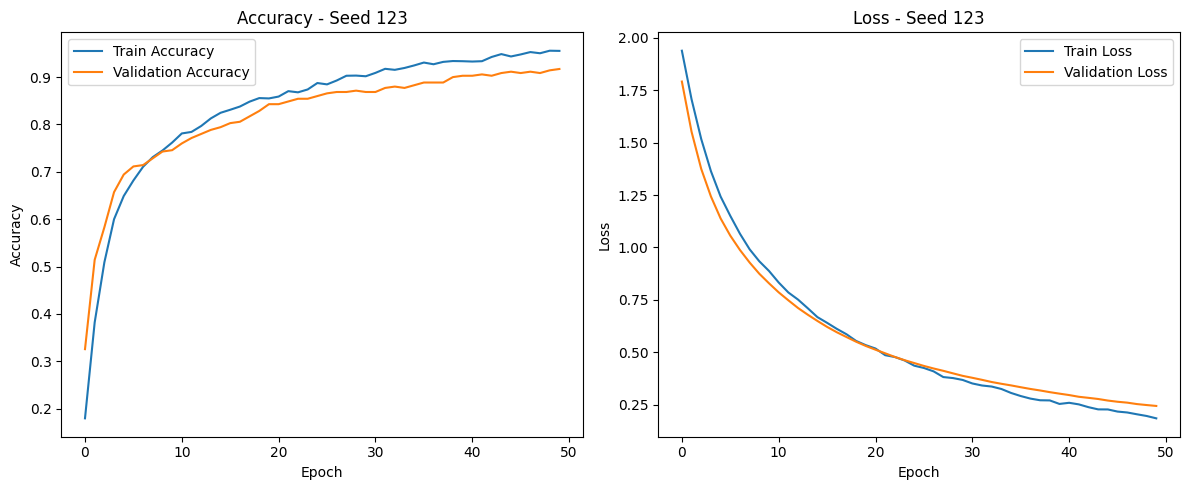


Running seed: 2024
Train: 2800
Validation: 350
Test: 350
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 307ms/step - accuracy: 0.1867 - loss: 1.9635 - val_accuracy: 0.3371 - val_loss: 1.7249
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.3473 - loss: 1.7115 - val_accuracy: 0.4971 - val_loss: 1.5044
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.4708 - loss: 1.5102 - val_accuracy: 0.6086 - val_loss: 1.3417
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.5645 - loss: 1.3696 - val_accuracy: 0.6571 - val_loss: 1.2142
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6471 - loss: 1.2448 - val_accuracy: 0.6886 - val_loss: 1.1124
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6870 - loss: 1.1488 - val_accuracy: 0.7171 - val_loss: 1.0269
Epoch 7/50
88/88 ━━━━━

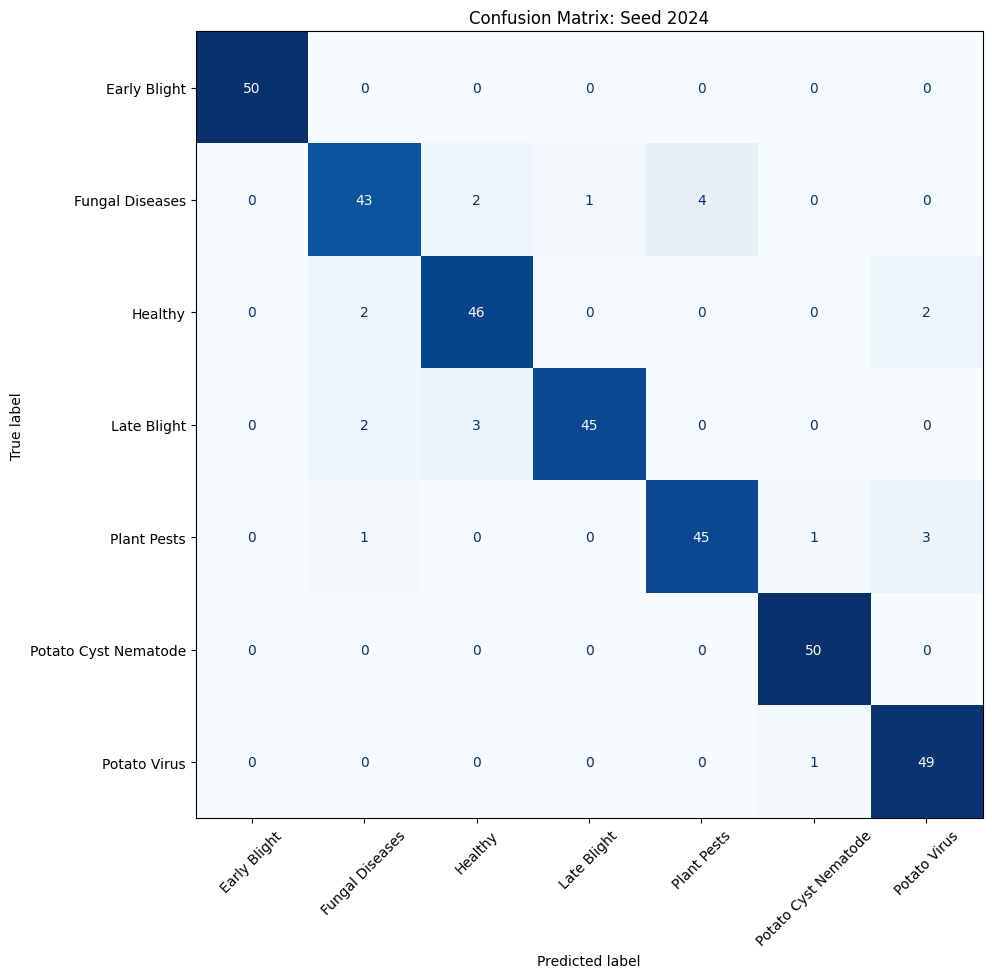

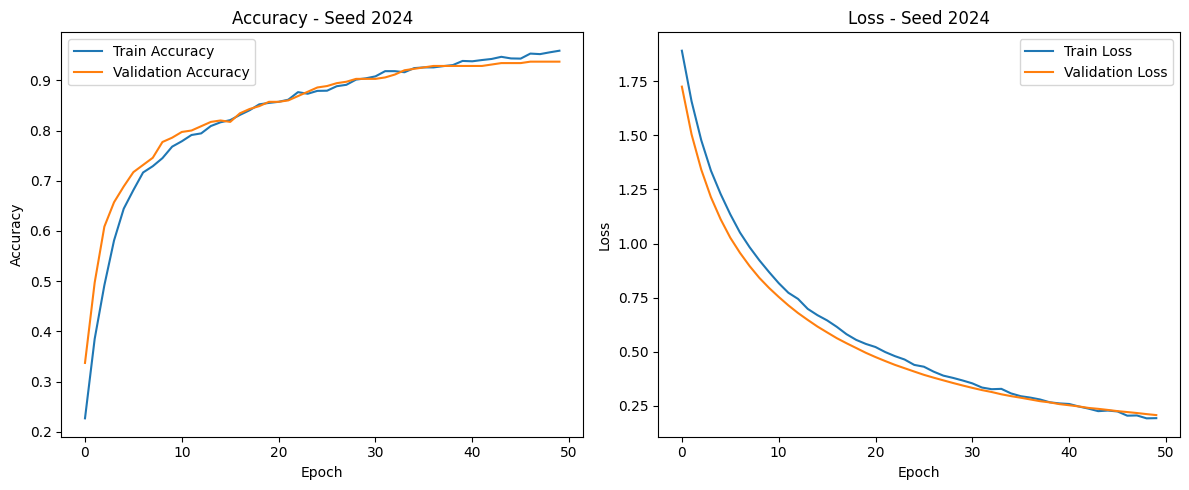


Running seed: 3407
Train: 2800
Validation: 350
Test: 350
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 51s 300ms/step - accuracy: 0.1716 - loss: 1.9699 - val_accuracy: 0.3629 - val_loss: 1.7552
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.3855 - loss: 1.7262 - val_accuracy: 0.5429 - val_loss: 1.5261
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.5359 - loss: 1.5071 - val_accuracy: 0.6257 - val_loss: 1.3590
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6050 - loss: 1.3696 - val_accuracy: 0.6800 - val_loss: 1.2334
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6724 - loss: 1.2129 - val_accuracy: 0.7086 - val_loss: 1.1309
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6948 - loss: 1.1233 - val_accuracy: 0.7286 - val_loss: 1.0516
Epoch 7/50
88/88 ━━━━━

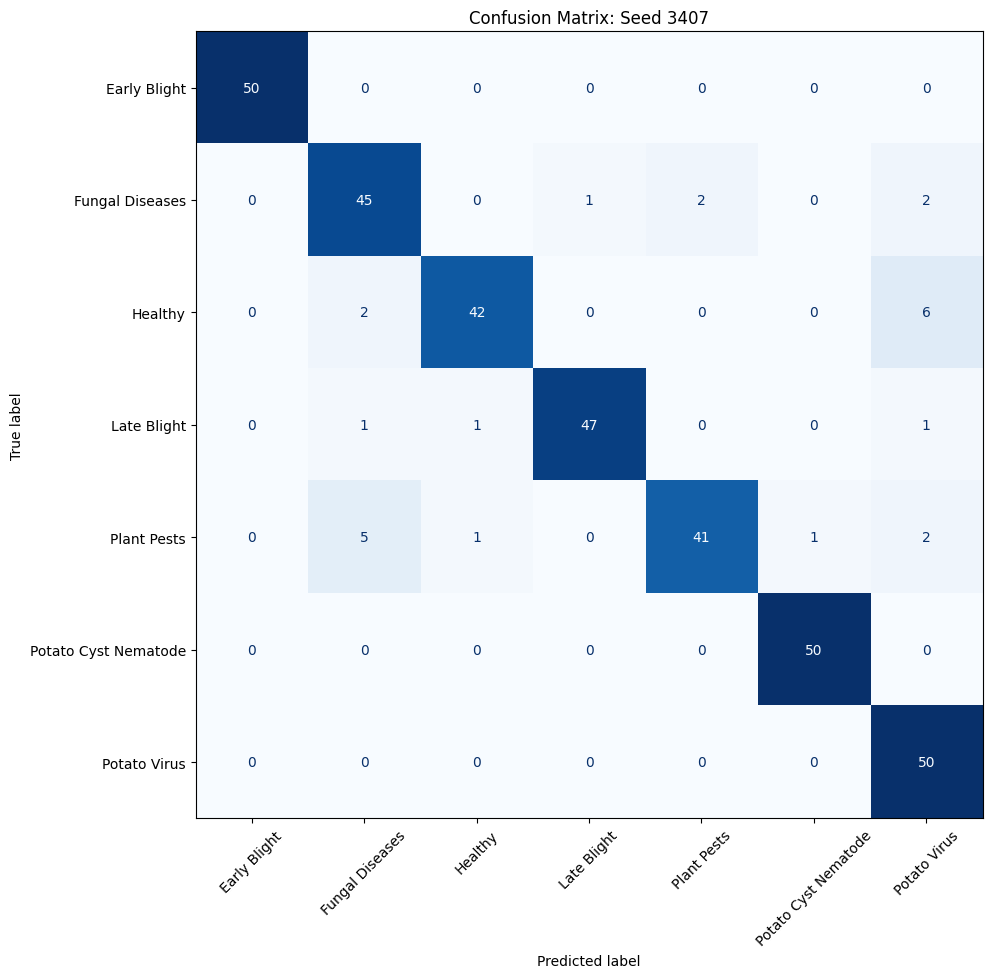

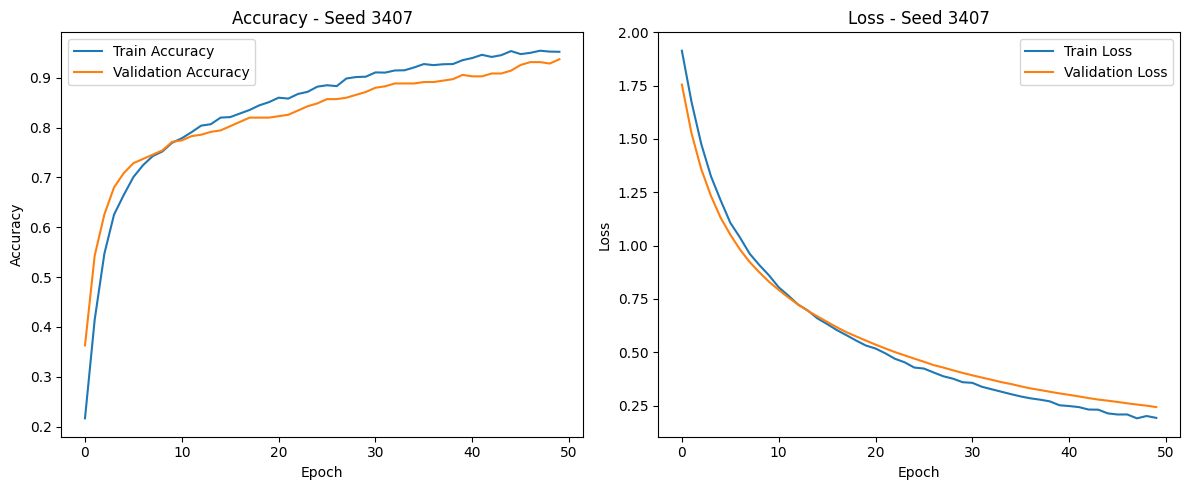


Running seed: 777
Train: 2800
Validation: 350
Test: 350
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}
Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 301ms/step - accuracy: 0.1653 - loss: 1.9755 - val_accuracy: 0.2886 - val_loss: 1.7804
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.3406 - loss: 1.7265 - val_accuracy: 0.4743 - val_loss: 1.5502
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.4921 - loss: 1.5364 - val_accuracy: 0.6086 - val_loss: 1.3791
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.5966 - loss: 1.3613 - val_accuracy: 0.6600 - val_loss: 1.2489
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6522 - loss: 1.2656 - val_accuracy: 0.7000 - val_loss: 1.1457
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6774 - loss: 1.1555 - val_accuracy: 0.7086 - val_loss: 1.0603
Epoch 7/50
88/88 ━━━━━━

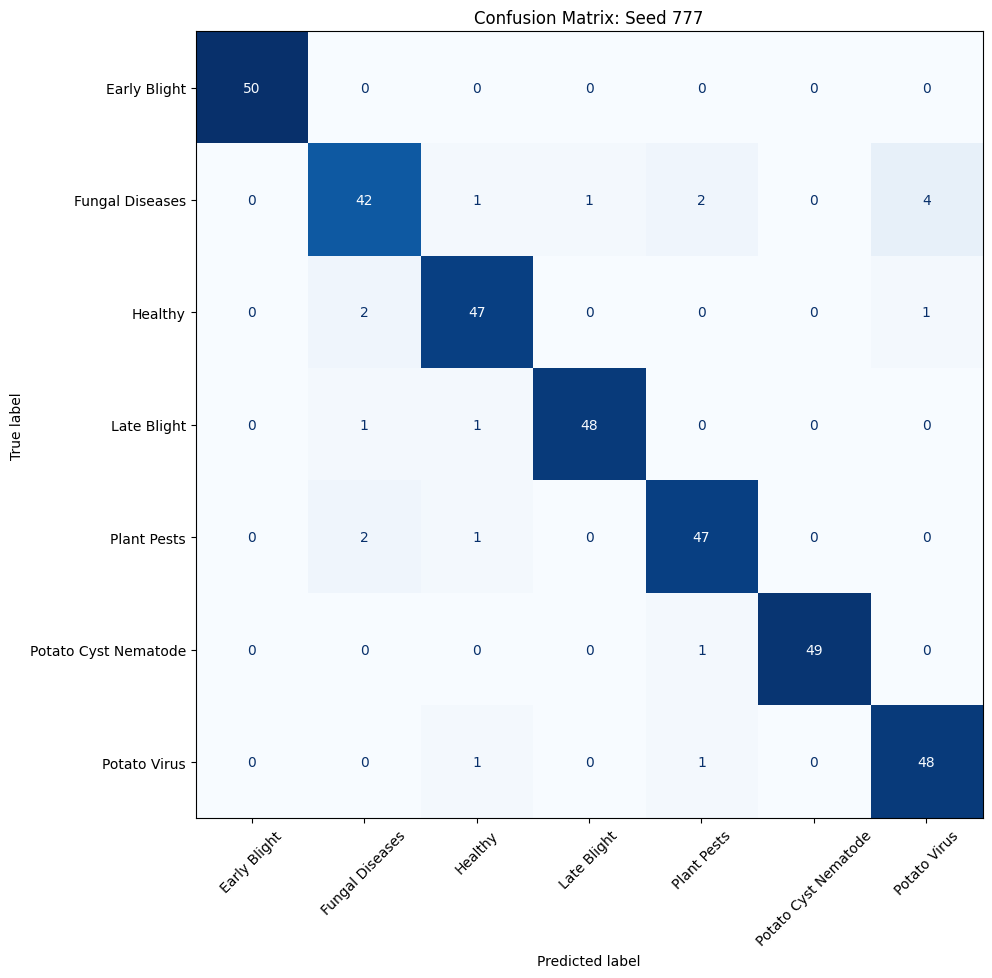

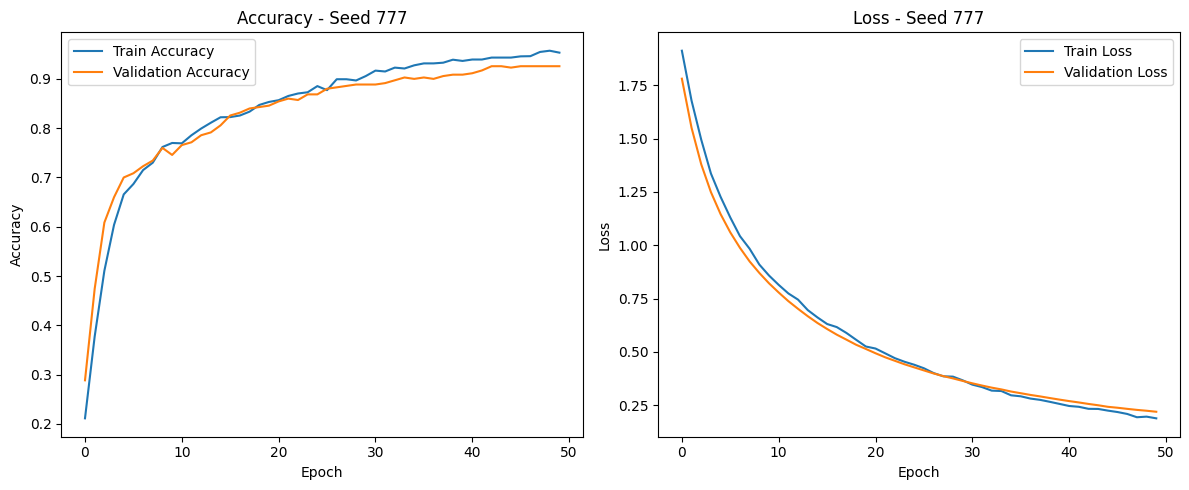


All seed results:
{'seed': 42, 'test_accuracy': 0.9399999976158142, 'test_loss': 0.20652583241462708, 'macro_precision': 0.9402334512490461, 'macro_recall': 0.9400000000000001, 'macro_f1': 0.939831873235992, 'weighted_precision': 0.9402334512490461, 'weighted_recall': 0.94, 'weighted_f1': 0.9398318732359922, 'model_path': 'models/EfficientNetB0_7class_seed_42.keras', 'history_path': 'history/EfficientNetB0_7class_seed_42_history.pkl', 'plot_path': 'history/EfficientNetB0_7class_seed_42_accuracy_loss.png', 'confusion_matrix_path': 'history/EfficientNetB0_7class_seed_42_confusion_matrix.png'}
{'seed': 123, 'test_accuracy': 0.9285714030265808, 'test_loss': 0.1967984437942505, 'macro_precision': 0.9304634717767414, 'macro_recall': 0.9285714285714286, 'macro_f1': 0.9282779591041702, 'weighted_precision': 0.9304634717767413, 'weighted_recall': 0.9285714285714286, 'weighted_f1': 0.9282779591041704, 'model_path': 'models/EfficientNetB0_7class_seed_123.keras', 'history_path': 'history/Efficien

In [8]:
all_results = []

for seed in SEEDS:
    result = run_single_seed(seed)
    all_results.append(result)

print("\nAll seed results:")
for result in all_results:
    print(result)


In [9]:
metrics = [
    "test_accuracy",
    "test_loss",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1"
]

print("\nMulti-seed summary:")
print("=" * 70)

for metric in metrics:
    values = np.array([result[metric] for result in all_results])
    mean_value = np.mean(values)
    std_value = np.std(values)

    print(f"{metric}: {mean_value:.4f} ± {std_value:.4f}")



Multi-seed summary:
test_accuracy: 0.9360 ± 0.0067
test_loss: 0.1993 ± 0.0072
macro_precision: 0.9376 ± 0.0054
macro_recall: 0.9360 ± 0.0067
macro_f1: 0.9358 ± 0.0067
weighted_precision: 0.9376 ± 0.0054
weighted_recall: 0.9360 ± 0.0067
weighted_f1: 0.9358 ± 0.0067


In [10]:
import pandas as pd

results_df = pd.DataFrame(all_results)
results_df.to_csv("EfficientNetB0_7class_multiseed_results.csv", index=False)

print("Saved multi-seed results to EfficientNetB0_7class_multiseed_results.csv")
results_df


Saved multi-seed results to EfficientNetB0_7class_multiseed_results.csv


,seed,test_accuracy,test_loss,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,model_path,history_path,plot_path,confusion_matrix_path
0,42,0.940000,0.206526,0.940233,0.940000,0.939832,0.940233,0.940000,0.939832,models/EfficientNetB0_7class_seed_42.keras,history/EfficientNetB0_7class_seed_42_history.pkl,history/EfficientNetB0_7class_seed_42_accuracy...,history/EfficientNetB0_7class_seed_42_confusio...
1,123,0.928571,0.196798,0.930463,0.928571,0.928278,0.930463,0.928571,0.928278,models/EfficientNetB0_7class_seed_123.keras,history/EfficientNetB0_7class_seed_123_history...,history/EfficientNetB0_7class_seed_123_accurac...,history/EfficientNetB0_7class_seed_123_confusi...
2,2024,0.937143,0.205615,0.937624,0.937143,0.936819,0.937624,0.937143,0.936819,models/EfficientNetB0_7class_seed_2024.keras,history/EfficientNetB0_7class_seed_2024_histor...,history/EfficientNetB0_7class_seed_2024_accura...,history/EfficientNetB0_7class_seed_2024_confus...
3,3407,0.928571,0.200681,0.933760,0.928571,0.928472,0.933760,0.928571,0.928472,models/EfficientNetB0_7class_seed_3407.keras,history/EfficientNetB0_7class_seed_3407_histor...,history/EfficientNetB0_7class_seed_3407_accura...,history/EfficientNetB0_7class_seed_3407_confus...
4,777,0.945714,0.186823,0.946001,0.945714,0.945571,0.946001,0.945714,0.945571,models/EfficientNetB0_7class_seed_777.keras,history/EfficientNetB0_7class_seed_777_history...,history/EfficientNetB0_7class_seed_777_accurac...,history/EfficientNetB0_7class_seed_777_confusi...
